/tmp/ipykernel_6921/842682667.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


--- Cross-Validation Correlation Table ---
        Corr_SMA_10  Corr_Momentum_5
Fold_1    -0.000434        -0.012121
Fold_2    -0.034947        -0.018140
Fold_3    -0.022790        -0.028516
Fold_4    -0.032971        -0.017017
Fold_5    -0.056802        -0.040691


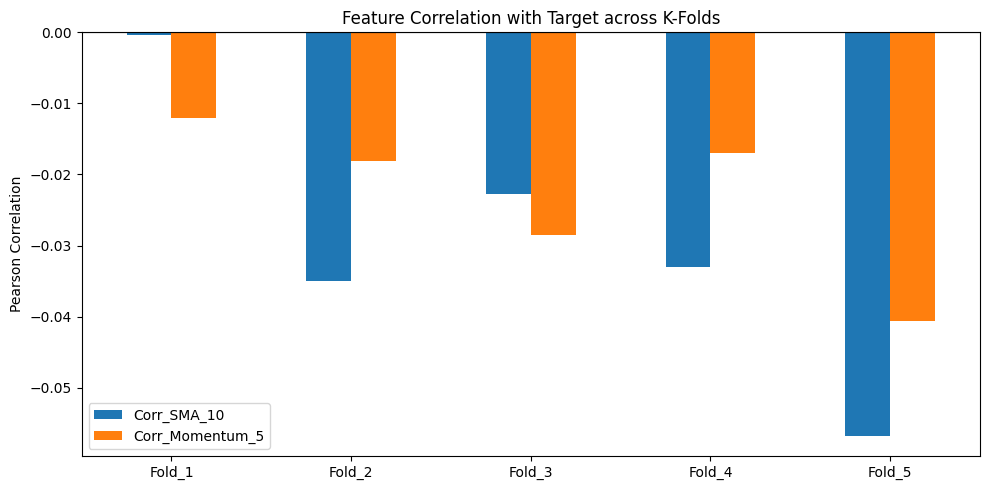

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# 1. Download Data
ticker = 'IVV'
df = yf.download(ticker, start='2020-01-01', end='2023-12-31')

# 2. Feature Engineering (Simple Technical Indicators)
df['Return'] = df['Close'].pct_change()
df['Target'] = np.where(df['Return'].shift(-1) > 0, 1, 0) # Predict next day direction
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['Momentum_5'] = df['Close'] - df['Close'].shift(5)

df = df.dropna()
features = ['SMA_10', 'Momentum_5']

# 3. K-Fold Cross Validation for Correlation
kf = KFold(n_splits=5, shuffle=False)
results = []

for train_idx, test_idx in kf.split(df):
    train_data = df.iloc[train_idx]

    # Calculate Pearson correlation between features and Target
    corr_sma = train_data['SMA_10'].corr(train_data['Target'])
    corr_mom = train_data['Momentum_5'].corr(train_data['Target'])
    results.append([corr_sma, corr_mom])

# 4. Reproduce Table
res_df = pd.DataFrame(results, columns=['Corr_SMA_10', 'Corr_Momentum_5'])
res_df.index = [f'Fold_{i+1}' for i in range(len(res_df))]
print("--- Cross-Validation Correlation Table ---")
print(res_df)

# 5. Reproduce Graphs
plt.figure(figsize=(10, 5))
res_df.plot(kind='bar', ax=plt.gca())
plt.title('Feature Correlation with Target across K-Folds')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

--- Alternative Data Head ---
            Sentiment_Score  Mention_Volume
Date                                       
2023-01-01         0.599343           30320
2023-01-02         0.472347            4748
2023-01-03         0.629538           32968
2023-01-04         0.804606           33562
2023-01-05         0.453169           14545

--- Summary Statistics ---
       Sentiment_Score  Mention_Volume
count       100.000000      100.000000
mean          0.479231    26020.700000
std           0.181634    14621.815414
min          -0.023949     1197.000000
25%           0.379819    13474.750000
50%           0.474609    26270.500000
75%           0.581190    38676.500000
max           0.870456    48357.000000


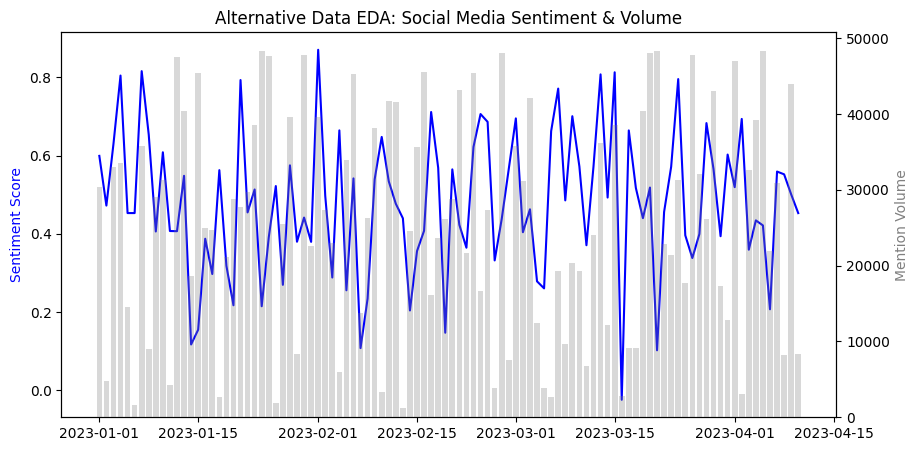

In [2]:
# Simulating Alternative Data Import (e.g., Twitter/Reddit Sentiment)
import datetime

dates = pd.date_range(start="2023-01-01", periods=100)
np.random.seed(42)
sentiment_scores = np.random.normal(loc=0.5, scale=0.2, size=100)
mention_volume = np.random.randint(1000, 50000, size=100)

alt_df = pd.DataFrame({
    'Date': dates,
    'Sentiment_Score': sentiment_scores,
    'Mention_Volume': mention_volume
}).set_index('Date')

# Exploratory Data Analysis (EDA)
print("--- Alternative Data Head ---")
print(alt_df.head())
print("\n--- Summary Statistics ---")
print(alt_df.describe())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(alt_df.index, alt_df['Sentiment_Score'], color='blue', label='Sentiment')
ax1.set_ylabel('Sentiment Score', color='blue')

ax2 = ax1.twinx()
ax2.bar(alt_df.index, alt_df['Mention_Volume'], color='gray', alpha=0.3, label='Volume')
ax2.set_ylabel('Mention Volume', color='gray')

plt.title('Alternative Data EDA: Social Media Sentiment & Volume')
plt.show()